<a href="https://colab.research.google.com/github/fazmina11/fazmina-codeboosters-2026/blob/main/Day3/Mini_project_Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = '4cd2754214fa45c03f9c355bb38c8ad9'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
CITIES = ['Mumbai', 'Tirupur', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Coimbatore', 'Jaipur']

print(f"API configured for {len(CITIES)} cities")
print(f"Cities: {CITIES}")

API configured for 8 cities
Cities: ['Mumbai', 'Tirupur', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Coimbatore', 'Jaipur']


In [ ]:
def fetch_weather(city, api_key):
  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)
    if response.status_code == 200:
      data = response.json()
      return {
          'city' : city,
          'temperature' : round(data['main']['temp'],1),
          'feels_like'  : round(data['main']['feels_like'],1),
          'humidity'    : data['main']['humidity'],
          'pressure'    : data['main']['pressure'],
          'wind_speed'  : data['wind']['speed'],
          'condition'   : data['weather'][0]['description'].title(),
          'visibility'  : data.get('visibility', 0)
      }
    else:
      print(f"ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}")
      return None

  except requests.exceptions.ConnectionError:
    print(f"CONNECTION ERROR for {city} - check internet connection")
    return None
  except requests.exceptions.Timeout:
    print(f"TIMEOUT for {city} - API did not respond in 10 second ")

  print('Calling Weather API...')
  weather_records =[]

  for city in CITIES:
    print(f" Fetching: {city}...", end='')
    record = fetch_weather(city, API_KEY)
    if record:
      weather_records.append(record)
      print(f" {record["temperature"]}°C, {record["condition"]}")
    else:
      print("FAILED")

  print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")

In [ ]:
print('Calling Weather API...')
weather_records =[]

for city in CITIES:
  print(f" Fetching: {city}...", end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f" {record["temperature"]}°C, {record["condition"]}")
    print("{")
    for key, value in record.items():
      print(f"  {key} : {value}")
    print("}\n")
  else:
    print("FAILED")

print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")

Calling Weather API...
 Fetching: Mumbai... 30.6°C, Clear Sky
{
  city : Mumbai
  temperature : 30.6
  feels_like : 37.6
  humidity : 79
  pressure : 1004
  wind_speed : 7.29
  condition : Clear Sky
  visibility : 10000
}

 Fetching: Tirupur... 27.3°C, Overcast Clouds
{
  city : Tirupur
  temperature : 27.3
  feels_like : 29.4
  humidity : 70
  pressure : 1008
  wind_speed : 8.55
  condition : Overcast Clouds
  visibility : 10000
}

 Fetching: Bangalore... 29.6°C, Overcast Clouds
{
  city : Bangalore
  temperature : 29.6
  feels_like : 31.2
  humidity : 55
  pressure : 1008
  wind_speed : 5.85
  condition : Overcast Clouds
  visibility : 10000
}

 Fetching: Chennai... 32.4°C, Overcast Clouds
{
  city : Chennai
  temperature : 32.4
  feels_like : 39.4
  humidity : 71
  pressure : 1003
  wind_speed : 3.13
  condition : Overcast Clouds
  visibility : 10000
}

 Fetching: Hyderabad... 32.5°C, Overcast Clouds
{
  city : Hyderabad
  temperature : 32.5
  feels_like : 33.4
  humidity : 42
  pre

In [ ]:

weather_df = pd.DataFrame(weather_records)
display(weather_df)

,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibility
0,Mumbai,30.6,37.6,79,1004,7.29,Clear Sky,10000
1,Tirupur,27.3,29.4,70,1008,8.55,Overcast Clouds,10000
2,Bangalore,29.6,31.2,55,1008,5.85,Overcast Clouds,10000
3,Chennai,32.4,39.4,71,1003,3.13,Overcast Clouds,10000
4,Hyderabad,32.5,33.4,42,1003,4.50,Overcast Clouds,10000
5,Kolkata,34.7,39.9,50,1000,7.42,Clear Sky,10000
6,Coimbatore,25.7,26.2,75,1009,6.36,Overcast Clouds,10000
7,Jaipur,27.3,27.5,47,1001,10.50,Few Clouds,10000


In [ ]:

weather_df=pd.DataFrame(weather_records)

print('Weather Dataframe created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData  types:')
print(weather_df.dtypes)

Weather Dataframe created:
      city  temperature  feels_like  humidity  pressure  wind_speed       condition  visibility
    Mumbai         30.6        37.6        79      1004        7.29       Clear Sky       10000
   Tirupur         27.3        29.4        70      1008        8.55 Overcast Clouds       10000
 Bangalore         29.6        31.2        55      1008        5.85 Overcast Clouds       10000
   Chennai         32.4        39.4        71      1003        3.13 Overcast Clouds       10000
 Hyderabad         32.5        33.4        42      1003        4.50 Overcast Clouds       10000
   Kolkata         34.7        39.9        50      1000        7.42       Clear Sky       10000
Coimbatore         25.7        26.2        75      1009        6.36 Overcast Clouds       10000
    Jaipur         27.3        27.5        47      1001       10.50      Few Clouds       10000

Shape: (8, 8)
Missing values: 0

Data  types:
city            object
temperature    float64
feels_like     f

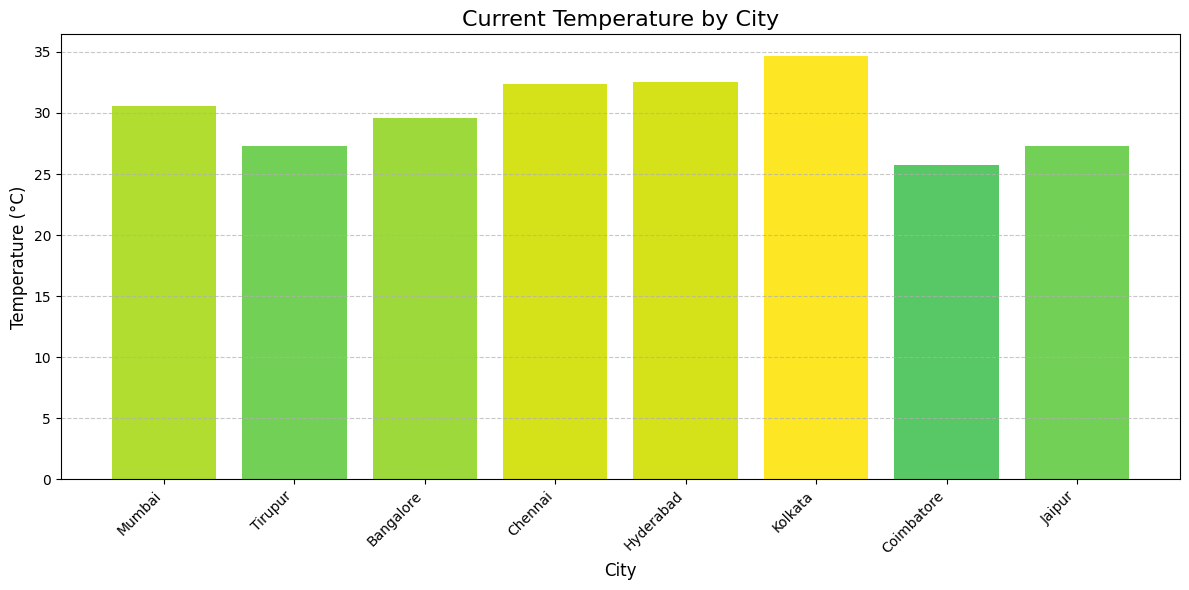

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(weather_df['city'], weather_df['temperature'], color=plt.cm.viridis(weather_df['temperature'] / weather_df['temperature'].max()))

plt.title('Current Temperature by City', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()